|<h2>Course:</h2>|<h1><a href="https://udemy.com/course/dullms_x/?couponCode=202508" target="_blank">A deep understanding of AI language model mechanisms</a></h1>|
|-|:-:|
|<h2>Part 2:</h2>|<h1>Large language models<h1>|
|<h2>Section:</h2>|<h1>Build a GPT<h1>|
|<h2>Lecture:</h2>|<h1><b>Working on the GPU<b></h1>|

<br>

<h5><b>Teacher:</b> Mike X Cohen, <a href="https://sincxpress.com" target="_blank">sincxpress.com</a></h5>
<h5><b>Course URL:</b> <a href="https://udemy.com/course/dullms_x/?couponCode=202508" target="_blank">udemy.com/course/dullms_x/?couponCode=202508</a></h5>
<i>Using the code without the course may lead to confusion or errors.</i>

In [1]:
# import libraries
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import time

# Select the processor device

In [2]:
## Note: To run models on a GPU you must select from the menu:
#   -> Runtime
#     -> Change runtime type
#       -> Hardware accelerator
#         -> GPU

In [3]:
# create a variable to access the GPU
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


# Build a simple model

In [4]:
# this model is constructed on the CPU
net = nn.Sequential(
    nn.Linear(20,100),
    nn.ReLU(),
    nn.Linear(100,500),
    nn.ReLU(),
    nn.Linear(500,30),
    nn.ReLU(),
    nn.Linear(30,2)
      )

# Make some data

In [5]:
# data are also created on the CPU
data   = torch.randn((1000,20)) # samples X features
labels = torch.randint(low=0,high=2,size=(1,1000))

# Send the model and the data to the GPU

In [6]:
# now send the model to the GPU
net.to(device)

# and send the data there
data   = data.to(device)
labels = labels.to(device)

In [7]:
data

tensor([[-0.2370,  0.5122, -0.3441,  ..., -0.2195,  2.0828, -0.6706],
        [ 0.6818,  0.3732, -0.6414,  ..., -0.8594, -0.3070, -0.9179],
        [ 0.4731,  0.4945,  0.3282,  ...,  0.2955, -1.2894,  0.5784],
        ...,
        [-1.7757,  1.2292, -0.0159,  ...,  0.1828,  0.8585, -0.4949],
        [ 0.2430,  0.7674,  0.1910,  ...,  1.4211, -1.1738, -1.2148],
        [ 0.1092,  1.5077,  0.8849,  ...,  1.3025,  0.5314, -1.1563]])

In [8]:
# you can also create data directly on the GPU
dataG = torch.randn((1000,20),device=device)
dataC = torch.randn((1000,20),device='cpu')

print(data.device)
print(dataG.device)
print(dataC.device)

cpu
cpu
cpu


# Getting results from the model

In [9]:
output = net(data)

In [10]:
output.device

device(type='cpu')

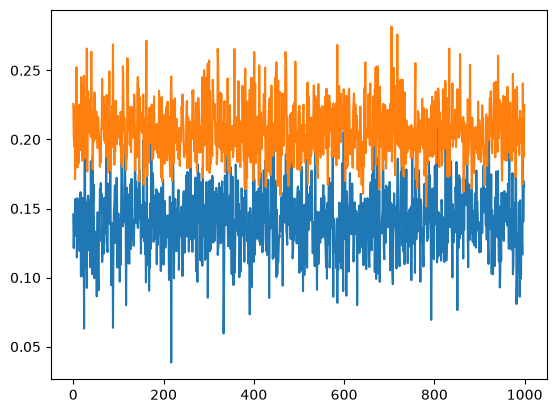

In [11]:
# try to plot the data
plt.plot(output.detach());

# plt.plot(output.detach().cpu());

# Experiment: Computation time

In [12]:
# synchronize the GPU and CPU (useful for timing computations; not a good idea for applications)
torch.cuda.synchronize()

# start the clock
starttime = time.process_time()

# move, run, retrieve
device = 'cuda:0'
net.to(device)
data   = data.to(device)
labels = labels.to(device)
output = net(data).detach().cpu()

# stop the clock
GPUtime = 1000*(time.process_time() - starttime)

AssertionError: Torch not compiled with CUDA enabled

In [ ]:
# start the clock
starttime = time.process_time()

# move, run, retrieve
device = 'cpu'
net.to(device)
data   = data.to(device)
labels = labels.to(device)
output = net(data).detach().cpu()

# stop the clock
CPUtime = 1000*(time.process_time() - starttime)

In [ ]:
# time in ms
print(f'CPU time: {CPUtime:.3f} milliseconds')
print(f'GPU time: {GPUtime:.3f} ms.')

In [ ]:
# maybe "sending" it to the CPU takes too much overhead?

In [ ]:
# recreate network and data
net  = nn.Sequential(nn.Linear(20,100),nn.ReLU(),nn.Linear(100,500),nn.ReLU(),nn.Linear(500,30),nn.ReLU(),nn.Linear(30,2))
data = torch.randn((1000,20))

# rerun the experiment
starttime = time.process_time()
output    = net(data).detach()
CPUtime2  = 1000*(time.process_time() - starttime)

# report the results
print(f'CPU  time: {CPUtime:.3f} ms')
print(f'CPU2 time: {CPUtime2:.3f} ms')
print(f'GPU  time: {GPUtime:.3f} ms')